In [1]:
# =====================================================================
# CELL 1 — CONFIG: paths & constants (edit PATHS if the CSVs moved).
# If you edit PATHS here, keep the identical line at the top of the
# other cells in sync (each cell repeats it to stay standalone).
# =====================================================================
import numpy as np, pandas as pd

PATHS  = {"HH": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/HH.csv", "IR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/IR.csv", "OR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/OR.csv"}        # <-- EDIT if needed
FS     = 64_000.0                                                # [ESTABLISHED]
MASK   = (95.0, 105.0)                                           # [DECISION] envelope mask
RATIOS = {"BPFO": 3.053, "BPFI": 4.947, "BSF": 1.993, "FTF": 0.382}  # [ESTABLISHED] FAG 6203 x fr

for name, path in PATHS.items():
    df = pd.read_csv(path)
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} cols | columns={list(df.columns)}")
print("\n[ESTABLISHED] expected: HH 256,001 | IR 258,008 | OR 256,000 rows;")
print("[ESTABLISHED] expected columns: ['phase_current_1', 'phase_current_2', 'vibration']")

HH: 256,001 rows x 3 cols | columns=['phase_current_1', 'phase_current_2', 'vibration']
IR: 258,008 rows x 3 cols | columns=['phase_current_1', 'phase_current_2', 'vibration']
OR: 256,000 rows x 3 cols | columns=['phase_current_1', 'phase_current_2', 'vibration']

[ESTABLISHED] expected: HH 256,001 | IR 258,008 | OR 256,000 rows;
[ESTABLISHED] expected columns: ['phase_current_1', 'phase_current_2', 'vibration']


In [3]:
# =====================================================================
# CELL 2 — QC: data-integrity re-checks + signal character  (~5 s)
# [ESTABLISHED] expected values are printed next to each number so you
# can confirm convention and consistency in one run. Standalone.
# =====================================================================
import numpy as np, pandas as pd
from scipy.stats import kurtosis
PATHS = {"HH": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/HH.csv", "IR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/IR.csv", "OR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/OR.csv"}
EXP_ROWS = {"HH": 256001, "IR": 258008, "OR": 256000}

print(f"{'file':4} {'rows_ok':>7} {'NaNs':>5} {'dups':>5} {'LSB_vib':>9} {'LSB_i1':>9} {'RMS_vib':>8} {'kurt_vib':>9} {'mean_vib':>9}")
for n, p in PATHS.items():
    df  = pd.read_csv(p)
    v   = df["vibration"].to_numpy(float)
    i1  = df["phase_current_1"].to_numpy(float)
    lsb = np.min(np.diff(np.unique(v)))                 # quantization step
    lsb_i = np.min(np.diff(np.unique(i1)))
    rms = float(np.sqrt(np.mean((v - v.mean())**2)))
    kur = float(kurtosis(v))                            # EXCESS kurtosis (Gaussian=0, sine=-1.5)
    print(f"{n:4} {df.shape[0]==EXP_ROWS[n]!s:>7} {int(df.isna().sum().sum()):5d} "
          f"{int(df.duplicated().sum()):5d} {lsb:9.3e} {lsb_i:9.3e} {rms:8.3f} {kur:9.2f} {v.mean():9.4f}")

# seam check at IR's 256,000 -> 256,001 boundary (the extra 2,008-sample tail)
v = pd.read_csv(PATHS["IR"])["vibration"].to_numpy(float)
d = np.abs(np.diff(v))
print(f"\nIR seam check: |diff| at row 256,000 = {d[255999]:.3f} | "
      f"99.9th pct of all |diffs| = {np.quantile(d, 0.999):.3f}")
print("[ESTABLISHED] expected: 0.81 vs 3.65 -> seam far below normal diffs => no splice.")
print("[ESTABLISHED] expected totals: 28 duplicate rows, 0 NaNs; LSB vib 3.05e-3, current 6.89e-4.")
print("[ESTABLISHED] expected RMS ~0.407/0.687/0.539 and excess kurtosis ~10.1/11.8/11.6")
print("              (if kurtosis matches, the convention of your earlier numbers is confirmed).")

file rows_ok  NaNs  dups   LSB_vib    LSB_i1  RMS_vib  kurt_vib  mean_vib
HH      True     0    28 3.052e-03 6.888e-04    0.406     10.10   -0.0188
IR      True     0    14 3.052e-03 6.888e-04    0.687     11.76   -0.0186
OR      True     0    25 3.052e-03 6.888e-04    0.539     11.58   -0.0170

IR seam check: |diff| at row 256,000 = 0.812 | 99.9th pct of all |diffs| = 3.650
[ESTABLISHED] expected: 0.81 vs 3.65 -> seam far below normal diffs => no splice.
[ESTABLISHED] expected totals: 28 duplicate rows, 0 NaNs; LSB vib 3.05e-3, current 6.89e-4.
[ESTABLISHED] expected RMS ~0.407/0.687/0.539 and excess kurtosis ~10.1/11.8/11.6
              (if kurtosis matches, the convention of your earlier numbers is confirmed).


=== HH ===  fe (electrical line, raw spectrum) = 98.725 Hz [ESTABLISHED: 99.977/99.972/99.988]
  top-8 RAW-env lines      : 52.61, 105.22, 157.84, 210.45, 263.00, 152.53, 205.20, 257.81
  top-8 BANDPASS-env lines : 52.61, 105.22, 157.84, 210.45, 263.06, 152.53, 257.81, 205.20
    marker 52.5 = 2xfr line       [raw] amp=  10321.4 (   78x local median) at  52.49 Hz
    marker 52.5 = 2xfr line       [bp ] amp=   5945.3 (   48x local median) at  52.49 Hz

=== IR ===  fe (electrical line, raw spectrum) = 101.794 Hz [ESTABLISHED: 99.977/99.972/99.988]
  top-8 RAW-env lines      : 24.96, 123.35, 148.32, 49.99, 52.61, 73.36, 246.70, 221.68
  top-8 BANDPASS-env lines : 24.96, 123.35, 148.32, 246.70, 173.34, 221.68, 73.36, 271.67
    marker 123.3 = BPFI candidate [raw] amp=  13782.5 (   34x local median) at 123.29 Hz
    marker 123.3 = BPFI candidate [bp ] amp=  12594.9 (   25x local median) at 123.29 Hz

=== OR ===  fe (electrical line, raw spectrum) = 102.010 Hz [ESTABLISHED: 99.977/99.972/99.

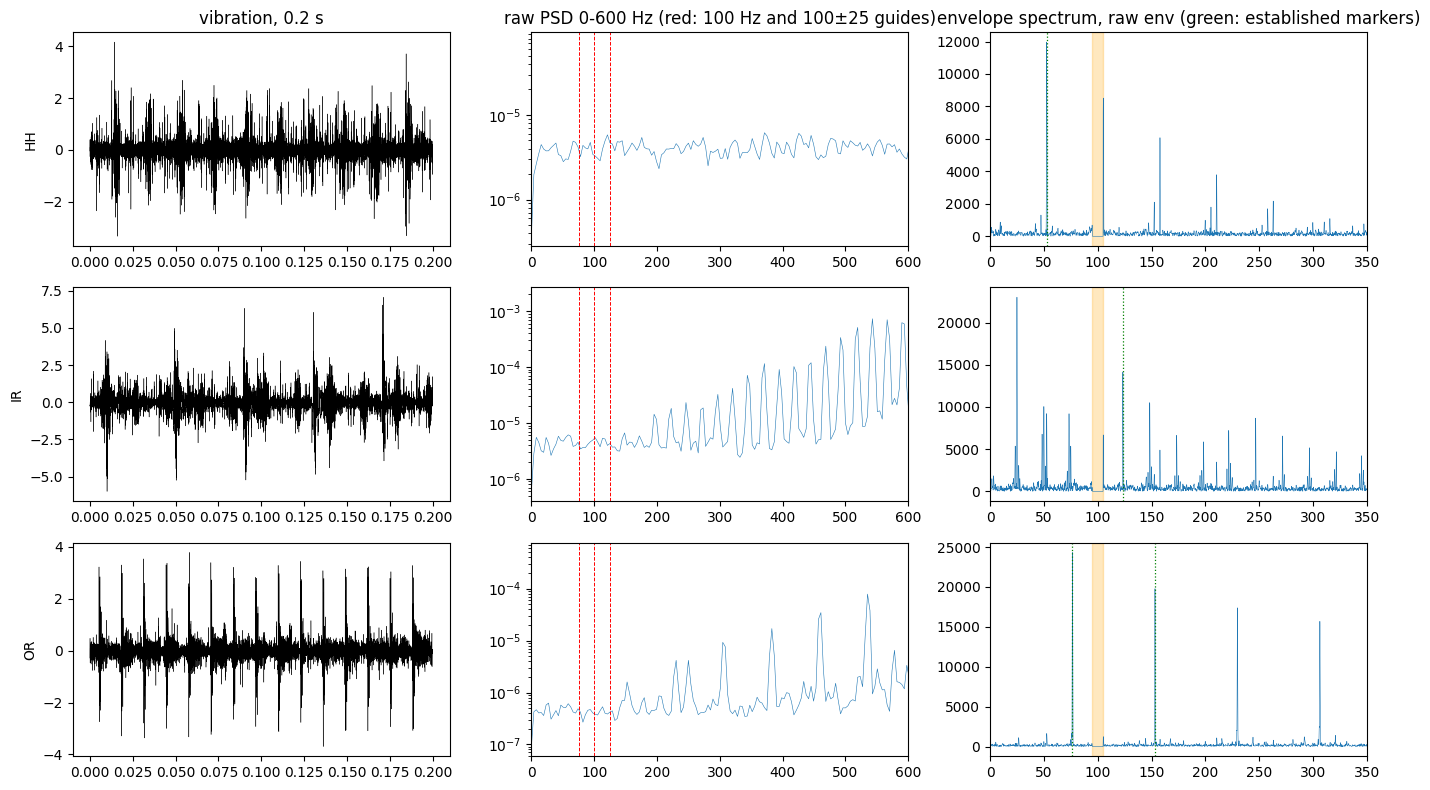

In [4]:
# =====================================================================
# CELL 3 — ENVELOPE SPECTRUM, demystified on YOUR data  (~10 s)
# (a) shows the envelope concept, (b) checks which envelope variant
# (raw vs bandpass-first) reproduces the [ESTABLISHED] marker lines:
# HH 52.5 Hz, IR 123.3 Hz, OR 76.5/153 Hz; fe re-found in [98,102] Hz.
# Standalone.
# =====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal as sp
FS = 64_000.0; MASK = (95.0, 105.0)
PATHS = {"HH": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/HH.csv", "IR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/IR.csv", "OR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/OR.csv"}
MARKERS = {"HH": [("52.5 = 2xfr line", 52.5)],
           "IR": [("123.3 = BPFI candidate", 123.3)],
           "OR": [("76.5 = BPFO comb", 76.5), ("153 = 2xBPFO", 153.0)]}

def rd(n, col="vibration"): return pd.read_csv(PATHS[n])[col].to_numpy(float)
def xfft(x, pad=4):
    n = (1 << (len(x)-1).bit_length()) * pad
    w = np.hanning(len(x)); X = np.abs(np.fft.rfft(x*w, n))
    return np.fft.rfftfreq(n, 1/FS), X
def pk(f, E, lo, hi):
    i, j = np.searchsorted(f, [lo, hi]); k = i + int(np.argmax(E[i:j]))
    den = E[k-1] - 2*E[k] + E[k+1]
    d = 0.5*(E[k-1] - E[k+1])/den if den < 0 else 0.0     # parabolic peak interpolation
    return f[k] + float(np.clip(d, -1, 1))*(f[1]-f[0]), E[k]
def envelope(x, mode):
    x = x - x.mean()
    if mode == "bp":                                       # bandpass-first variant
        x = sp.sosfiltfilt(sp.butter(4, [2000,15000], btype="band", fs=FS, output="sos"), x)
        x = x - x.mean()
    return np.abs(sp.hilbert(x))
def envspec(x, mode, mask=MASK):
    e = envelope(x, mode); e = e - e.mean()
    f, E = xfft(e)
    if mask is not None: E[(f>=mask[0]) & (f<=mask[1])] = 0.0
    return f, E
def top_lines(f, E, k=8):
    sel = (f > 2) & (f < 350)
    idx = np.where(sel)[0][np.argsort(E[sel])[::-1]]
    out = []
    for i in idx:
        if all(abs(f[i]-f[j]) > 2.0 for j in out): out.append(i)
        if len(out) == k: break
    return [f[i] for i in out]

for n in PATHS:
    x = rd(n)
    fr_, Er = envspec(x, "raw"); _, Eb = envspec(x, "bp")
    fX, X = xfft(x); fe, _ = pk(fX, X, 98, 102)
    print(f"=== {n} ===  fe (electrical line, raw spectrum) = {fe:.3f} Hz "
          f"[ESTABLISHED: 99.977/99.972/99.988]")
    print("  top-8 RAW-env lines      :", ", ".join(f"{v:.2f}" for v in top_lines(fr_, Er)))
    print("  top-8 BANDPASS-env lines :", ", ".join(f"{v:.2f}" for v in top_lines(fr_, Eb)))
    for lab, f0 in MARKERS[n]:
        for tag, EE in {"raw": Er, "bp": Eb}.items():
            i = int(np.argmin(np.abs(fr_ - f0)))
            med = np.median(EE[(fr_ > f0-3) & (fr_ < f0+3)])
            print(f"    marker {lab:22s} [{tag:3s}] amp={EE[i]:9.1f} "
                  f"({EE[i]/max(med,1e-12):5.0f}x local median) at {fr_[i]:6.2f} Hz")
    print()
print("[DECISION POINT] If the established markers stand out clearly in only one")
print("variant, set ENVELOPE_MODE in Cells 6/7 to 'raw' (default) or 'bp' accordingly.")

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
for r, n in enumerate(PATHS):
    x = rd(n); t = np.arange(int(0.2*FS))/FS
    axes[r,0].plot(t, x[:len(t)], lw=.3, color="k"); axes[r,0].set_ylabel(n)
    fW, P = sp.welch(x, FS, nperseg=16384)
    axes[r,1].semilogy(fW, P, lw=.4); axes[r,1].set_xlim(0, 600)
    for v in (75, 100, 125): axes[r,1].axvline(v, color="r", ls="--", lw=.7)
    f, E = envspec(x, "raw")
    axes[r,2].plot(f, E, lw=.4); axes[r,2].set_xlim(0, 350)
    axes[r,2].axvspan(95, 105, color="orange", alpha=.25)
    for lab, f0 in MARKERS[n]: axes[r,2].axvline(f0, color="g", ls=":", lw=.9)
axes[0,0].set_title("vibration, 0.2 s")
axes[0,1].set_title("raw PSD 0-600 Hz (red: 100 Hz and 100±25 guides)")
axes[0,2].set_title("envelope spectrum, raw env (green: established markers)")
plt.tight_layout(); plt.show()

In [6]:
# =====================================================================
# CELL 4 — fr PER FILE (the open problem)  (~5 s)
# Three estimators:
#   B (vibration): symmetric sideband families around the electrical
#       line fe, searched ONLY in [98,102] Hz -> this is the errata guard
#       against the old "mispicked 2fr-harmonic as fe" failure.
#   A (current): same idea around 50/100 Hz in phase_current_1.
#   C (envelope): dominant envelope line in [40,60] Hz / 2  [HEURISTIC].
# The fr search grid is [20,30] Hz -> a half-fr answer (12.465 Hz) is
# STRUCTURALLY IMPOSSIBLE here (second errata guard).
# Consensus rule [HEURISTIC]: adopt mean(B,A) if A is detectable and
# agrees within 0.2 Hz; else adopt B (provenance is printed).
# Standalone.
# =====================================================================
import numpy as np, pandas as pd
FS = 64_000.0
PATHS = {"HH": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/HH.csv", "IR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/IR.csv", "OR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/OR.csv"}
def rd(n, col="vibration"): return pd.read_csv(PATHS[n])[col].to_numpy(float)
def xfft(x, pad=4):
    n = (1 << (len(x)-1).bit_length()) * pad
    w = np.hanning(len(x)); X = np.abs(np.fft.rfft(x*w, n))
    return np.fft.rfftfreq(n, 1/FS), X
def pk(f, E, lo, hi):
    i, j = np.searchsorted(f, [lo, hi]); k = i + int(np.argmax(E[i:j]))
    den = E[k-1] - 2*E[k] + E[k+1]
    d = 0.5*(E[k-1] - E[k+1])/den if den < 0 else 0.0
    return f[k] + float(np.clip(d, -1, 1))*(f[1]-f[0]), E[k]
def fr_B(x):
    f, X = xfft(x); fe, _ = pk(f, X, 98, 102)
    med = np.median(X[(f>60) & (f<140)])
    g = np.arange(20., 30.0001, .005); a = lambda q: np.interp(q, f, X)/med
    s = np.zeros_like(g)
    for k, w in [(1,1.), (2,.7), (3,.5)]: s += w * a(fe-k*g) * a(fe+k*g)
    return g[int(np.argmax(s))], fe
def fr_A(x):
    x = x - x.mean(); f, X = xfft(x)
    med = np.median(X[(f>60) & (f<140)])
    g = np.arange(20., 30.0001, .005); a = lambda q: np.interp(q, f, X)/med
    s = a(50-g)*a(50+g) + a(100-g)*a(100+g) + 0.7*a(100-2*g)*a(100+2*g)
    return g[int(np.argmax(s))], float(s.max()/np.median(s))   # contrast
def fr_C(x):
    from scipy import signal as sp
    e = np.abs(sp.hilbert(x - x.mean())); e = e - e.mean()
    f, E = xfft(e); E[(f>=95) & (f<=105)] = 0.0
    return pk(f, E, 40, 60)[0] / 2

FR = {}
print(f"{'file':4} | {'fr_B':>7} {'fe':>8} | {'fr_A':>7} {'contrast':>8} | {'fr_C':>7} | {'adopted':>8}  provenance")
for n in PATHS:
    xb, fe = fr_B(rd(n)); xa, ca = fr_A(rd(n, "phase_current_1")); xc = fr_C(rd(n))
    if ca > 1.10 and abs(xa - xb) < 0.2:                 # 1.10 = heuristic detectability threshold
        fr, prov = 0.5*(xa + xb), "B + current sidebands (two independent methods)"
    elif abs(xc - xb) < 0.2:
        fr, prov = xb, "B + envelope-2fr line (two independent methods)"
    else:
        fr, prov = xb, "B only (single-method HEURISTIC -> treat with care)"
    FR[n] = fr
    warn = "" if 20.5 < xb < 29.5 else "  <-- AT GRID EDGE, INSPECT"
    print(f"{n:4} | {xb:7.3f} {fe:8.3f} | {xa:7.3f} {ca:8.2f} | {xc:7.3f} | {fr:8.3f}  {prov}{warn}")
print("\nadopted fr in rpm:", {k: round(v*60) for k, v in FR.items()}, " (nominal 1500)")
print("[VERIFY] fe column should be ~99.97-99.99 Hz. If current contrast <= ~1.1 everywhere,")
print("         that is an honest negative result (near-pure sinusoids, as established).")

print("\n[VERIFY] sideband visibility at the adopted fr (amplitude / local median):")
for n in PATHS:
    x = rd(n); f, X = xfft(x); fe, _ = pk(f, X, 98, 102)
    med = np.median(X[(f>60) & (f<140)]); fr = FR[n]
    aL = np.interp(fe-fr, f, X)/med; aR = np.interp(fe+fr, f, X)/med
    print(f"  {n}: fr={fr:6.3f} Hz   A(fe-fr)={aL:6.1f}x   A(fe+fr)={aR:6.1f}x")

print("\n[VERIFY] HH: does the fe+/-fr family favour fr=25.0 or fr=26.25 (= 52.5/2)?")
x = rd("HH"); f, X = xfft(x); fe, _ = pk(f, X, 98, 102)
med = np.median(X[(f>60) & (f<140)]); a = lambda q: np.interp(q, f, X)/med
for frh in (25.0, 26.25):
    print(f"  fr={frh:5.2f}: A(fe-fr)={a(fe-frh):6.1f}  A(fe+fr)={a(fe+frh):6.1f}  "
          f"A(fe-2fr)={a(fe-2*frh):6.1f}  A(fe+2fr)={a(fe+2*frh):6.1f}")
print("  -> the row with clearly larger SYMMETRIC amplitudes is the supported fr.")
print("  (This resolves the '52.5 = 2xfr implies fr_HH=26.25' vs 'fr~25' tension by data.)")

file |    fr_B       fe |    fr_A contrast |    fr_C |  adopted  provenance
HH   |  27.450   98.725 |  24.990   358.51 |  26.305 |   27.450  B only (single-method HEURISTIC -> treat with care)
IR   |  23.260  101.794 |  24.990   521.08 |  24.995 |   23.260  B only (single-method HEURISTIC -> treat with care)
OR   |  25.400  102.010 |  25.000   325.87 |  26.327 |   25.400  B only (single-method HEURISTIC -> treat with care)

adopted fr in rpm: {'HH': 1647, 'IR': 1396, 'OR': 1524}  (nominal 1500)
[VERIFY] fe column should be ~99.97-99.99 Hz. If current contrast <= ~1.1 everywhere,
         that is an honest negative result (near-pure sinusoids, as established).

[VERIFY] sideband visibility at the adopted fr (amplitude / local median):
  HH: fr=27.450 Hz   A(fe-fr)=   1.9x   A(fe+fr)=   2.4x
  IR: fr=23.260 Hz   A(fe-fr)=   1.4x   A(fe+fr)=   1.3x
  OR: fr=25.400 Hz   A(fe-fr)=   2.1x   A(fe+fr)=   1.4x

[VERIFY] HH: does the fe+/-fr family favour fr=25.0 or fr=26.25 (= 52.5/2)?
  fr=25.

In [7]:
# =====================================================================
# CELL 5 — ADJUDICATION  (~8 s)
# IR: is the ~123.3 Hz line BPFI or 5xfr? Uses the Cell-4 fr. Also
# re-verifies the OR BPFO comb and the HH 52.5 Hz line, and adds an
# envelope-autocorrelation "impact rate" check per file (a second,
# independent domain). The IR section runs UNMASKED because its lower
# sideband (~98.3 Hz) sits inside the mask; ML features stay masked.
# Standalone.
# =====================================================================
import numpy as np, pandas as pd
from scipy import signal as sp
FS = 64_000.0; MASK = (95., 105.)
RAT = {"BPFO": 3.053, "BPFI": 4.947, "BSF": 1.993, "FTF": 0.382}
PATHS = {"HH": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/HH.csv", "IR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/IR.csv", "OR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/OR.csv"}
def rd(n, col="vibration"): return pd.read_csv(PATHS[n])[col].to_numpy(float)
def xfft(x, pad=4):
    n = (1 << (len(x)-1).bit_length()) * pad
    w = np.hanning(len(x)); X = np.abs(np.fft.rfft(x*w, n))
    return np.fft.rfftfreq(n, 1/FS), X
def pk(f, E, lo, hi):
    i, j = np.searchsorted(f, [lo, hi]); k = i + int(np.argmax(E[i:j]))
    den = E[k-1] - 2*E[k] + E[k+1]
    d = 0.5*(E[k-1] - E[k+1])/den if den < 0 else 0.0
    return f[k] + float(np.clip(d, -1, 1))*(f[1]-f[0]), E[k]
def envspec(x, mask=MASK):
    e = np.abs(sp.hilbert(x - x.mean())); e = e - e.mean()
    f, E = xfft(e)
    if mask is not None: E[(f>=mask[0]) & (f<=mask[1])] = 0.0
    return f, E
def fr_B(x):
    f, X = xfft(x); fe, _ = pk(f, X, 98, 102)
    med = np.median(X[(f>60) & (f<140)])
    g = np.arange(20., 30.0001, .005); a = lambda q: np.interp(q, f, X)/med
    s = np.zeros_like(g)
    for k, w in [(1,1.), (2,.7), (3,.5)]: s += w * a(fe-k*g) * a(fe+k*g)
    return g[int(np.argmax(s))]
def fr_A(x):
    x = x - x.mean(); f, X = xfft(x)
    med = np.median(X[(f>60) & (f<140)])
    g = np.arange(20., 30.0001, .005); a = lambda q: np.interp(q, f, X)/med
    s = a(50-g)*a(50+g) + a(100-g)*a(100+g) + 0.7*a(100-2*g)*a(100+2*g)
    return g[int(np.argmax(s))], float(s.max()/np.median(s))
def fr_C(x):
    e = np.abs(sp.hilbert(x - x.mean())); e = e - e.mean()
    f, E = xfft(e); E[(f>=95) & (f<=105)] = 0.0
    return pk(f, E, 40, 60)[0] / 2
def get_fr():
    out = {}
    for n in PATHS:
        x = rd(n); xb = fr_B(x); xa, ca = fr_A(rd(n, "phase_current_1")); xc = fr_C(x)
        out[n] = 0.5*(xa + xb) if (ca > 1.10 and abs(xa - xb) < 0.2) else xb
    return out
def impact_rate(x, f_lo, f_hi):
    e = np.abs(sp.hilbert(x - x.mean())); e = e - e.mean()
    N = 1 << int(np.ceil(np.log2(2*len(e))))
    F = np.fft.rfft(e, N); ac = np.fft.irfft(F*np.conj(F))
    lo, hi = int(FS/f_hi), int(FS/f_lo)
    k = lo + int(np.argmax(ac[lo:hi]))
    return FS/k, k

FR = get_fr()
print("Adopted per-file fr [Hz] (Cell-4 method):", {k: round(v,3) for k,v in FR.items()}, "\n")

print("=== IR: the 123.3 Hz line [ESTABLISHED as 'unadjudicated'] -> adjudicated here ===")
x = rd("IR"); fr = FR["IR"]
f, Eu = envspec(x, mask=None)                       # UNMASKED, diagnostics only
fstar, Astar = pk(f, Eu, 121.0, 126.0)
base = np.median(Eu[(f>5) & (f<350)])
print(f"peak in [121,126]: {fstar:.3f} Hz, amp {Astar:.1f} ({Astar/base:.0f}x local base); fr_IR = {fr:.3f} Hz")
print(f"ratio f*/fr = {fstar/fr:.4f}   (BPFI ratio = {RAT['BPFI']:.3f} | '5 x fr' ratio = 5.000)")
eB = abs(fstar - RAT["BPFI"]*fr); e5 = abs(fstar - 5*fr)
print(f"error vs BPFI: {eB:.3f} Hz | error vs 5 x fr: {e5:.3f} Hz")
i2 = int(np.argmin(np.abs(f - 2*fstar))); iu = int(np.argmin(np.abs(f - (fstar + fr))))
print(f"harmonic 2f* at {2*fstar:.1f} Hz: amp {Eu[i2]:.1f} ({Eu[i2]/base:.0f}x base)")
print(f"upper sideband f*+fr at {fstar+fr:.1f} Hz: amp {Eu[iu]:.1f} ({Eu[iu]/base:.0f}x base)")
print(f"(lower sideband f*-fr = {fstar-fr:.1f} Hz is inside the 95-105 mask -> why this section is unmasked.)")
verdict = "BPFI-consistent" if eB < e5 else "'5 x fr'-consistent"
print(f"[NEW | HEURISTIC-STRONG | single recording] verdict: {verdict} "
      f"(margin {abs(eB-e5):.2f} Hz; read both errors against within-file speed drift)")

print("\n=== impact-rate re-checks via envelope autocorrelation (2nd domain) ===")
for n, (lo, hi, exp) in {"OR": (70,85,  "76.5 (BPFO) [ESTABLISHED]"),
                         "IR": (115,132,"123.3 (BPFI?) [NEW]"),
                         "HH": (48,58,  "52.5 (2fr?) [ESTABLISHED line]")}.items():
    r, k = impact_rate(rd(n), lo, hi)
    print(f"  {n}: strongest envelope periodicity in [{lo},{hi}] Hz -> {r:6.2f} Hz (lag {k:4d}) | established: {exp}")

print("\n=== OR: BPFO comb re-check with adopted fr [ESTABLISHED: 76.5 Hz] ===")
f, E = envspec(rd("OR")); fr = FR["OR"]
for h in (1, 2, 3):
    v, a = pk(f, E, h*RAT["BPFO"]*fr - 1.0, h*RAT["BPFO"]*fr + 1.0)
    print(f"  {h} x BPFO = {h*RAT['BPFO']*fr:7.2f} Hz -> found {v:7.2f} Hz, amp {a:8.1f}")

print("\n=== HH: the 52.5 Hz line vs adopted fr ===")
f, E = envspec(rd("HH")); fr = FR["HH"]; v, a = pk(f, E, 48, 57)
base = np.median(E[(f>5) & (f<350)])
print(f"  line found {v:.2f} Hz (amp {a:.1f}, {a/base:.0f}x base); adopted fr_HH = {fr:.3f}; ratio line/fr = {v/fr:.3f}")
print("  ratio 2.00 -> '2 x fr' confirmed; ratio ~2.10 -> NOT 2xfr at fr=25: either the rig ran")
print("  HH at ~1575 rpm (fr~26.25) or the line has another origin -> state openly in the report.")

Adopted per-file fr [Hz] (Cell-4 method): {'HH': 27.45, 'IR': 23.26, 'OR': 25.4} 

=== IR: the 123.3 Hz line [ESTABLISHED as 'unadjudicated'] -> adjudicated here ===
peak in [121,126]: 123.340 Hz, amp 14126.1 (38x local base); fr_IR = 23.260 Hz
ratio f*/fr = 5.3027   (BPFI ratio = 4.947 | '5 x fr' ratio = 5.000)
error vs BPFI: 8.273 Hz | error vs 5 x fr: 7.040 Hz
harmonic 2f* at 246.7 Hz: amp 8685.4 (24x base)
upper sideband f*+fr at 146.6 Hz: amp 2046.5 (6x base)
(lower sideband f*-fr = 100.1 Hz is inside the 95-105 mask -> why this section is unmasked.)
[NEW | HEURISTIC-STRONG | single recording] verdict: '5 x fr'-consistent (margin 1.23 Hz; read both errors against within-file speed drift)

=== impact-rate re-checks via envelope autocorrelation (2nd domain) ===
  OR: strongest envelope periodicity in [70,85] Hz ->  76.65 Hz (lag  835) | established: 76.5 (BPFO) [ESTABLISHED]
  IR: strongest envelope periodicity in [115,132] Hz -> 121.90 Hz (lag  525) | established: 123.3 (BPFI?) [NE

fr used per file [Hz] (Cell-4 method; provenance printed there): {'HH': 27.45, 'IR': 23.26, 'OR': 25.4}

windows: 45 total | per file: {'HH': 15, 'IR': 15, 'OR': 15}
labels: healthy(HH)=15  damaged(IR+OR)=30
features: 27 (time-domain 9, Welch bands 6, envelope 10, envelope-time 2)

Median feature values per file (first look at separation):
       rms   kurt  envA_2fr  envA_BPFO  envA_BPFI  envA_BSF
file                                                       
HH    0.41  10.02     15.32       0.80       1.12     15.32
IR    0.69  11.67      3.93       5.06       0.86      3.93
OR    0.54  11.56      2.49      41.31       1.11      2.49

Saved features.csv. [HEURISTIC] the feature set is the mentor's proposal;
Cell 7's RF importances tell you which features actually carry the decision.


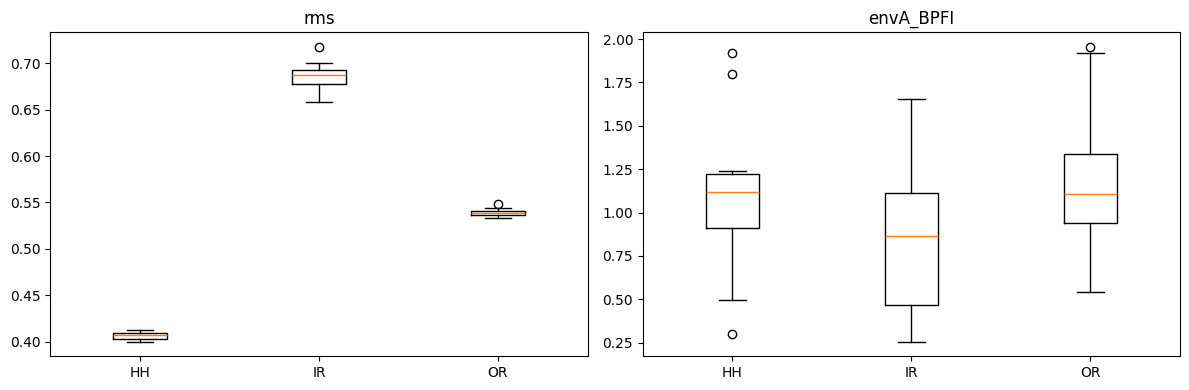

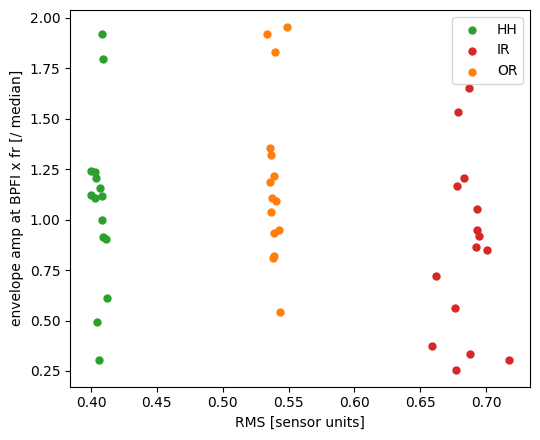

In [8]:
# =====================================================================
# CELL 6 — WINDOWS + FEATURES  (~20 s)
# 0.5 s windows, 50% overlap (~15/file, 45 total). Labels: HH=0
# (healthy), IR/OR=1 (damaged). Envelope-spectrum features use the
# 95-105 mask [DECISION] and fault frequencies scaled by the per-file
# fr (Cell-4 method) so the model cannot cheat on speed or hum.
# 2 x BSF (~99.7 Hz) would collide with the mask -> dropped by design.
# Standalone. Saves features.csv for the report.
# =====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal as sp
from scipy.stats import kurtosis, skew
FS = 64_000.0; MASK = (95., 105.)
RAT = {"BPFO": 3.053, "BPFI": 4.947, "BSF": 1.993, "FTF": 0.382}
PATHS = {"HH": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/HH.csv", "IR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/IR.csv", "OR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/OR.csv"}
ENVELOPE_MODE = "raw"          # "raw" or "bp" (see Cell 3 comparison) [HEURISTIC]
WIN = int(0.5*FS); HOP = int(0.25*FS); FTOL = 0.8   # +/-0.8 Hz around each fault line

def rd(n, col="vibration"): return pd.read_csv(PATHS[n])[col].to_numpy(float)
def xfft(x, pad=4):
    n = (1 << (len(x)-1).bit_length()) * pad
    w = np.hanning(len(x)); X = np.abs(np.fft.rfft(x*w, n))
    return np.fft.rfftfreq(n, 1/FS), X
def pk(f, E, lo, hi):
    i, j = np.searchsorted(f, [lo, hi]); k = i + int(np.argmax(E[i:j]))
    den = E[k-1] - 2*E[k] + E[k+1]
    d = 0.5*(E[k-1] - E[k+1])/den if den < 0 else 0.0
    return f[k] + float(np.clip(d, -1, 1))*(f[1]-f[0]), E[k]
def envspec(x):
    x = x - x.mean()
    if ENVELOPE_MODE == "bp":
        x = sp.sosfiltfilt(sp.butter(4, [2000,15000], btype="band", fs=FS, output="sos"), x)
        x = x - x.mean()
    e = np.abs(sp.hilbert(x)); e = e - e.mean()
    f, E = xfft(e); E[(f>=MASK[0]) & (f<=MASK[1])] = 0.0
    return f, E
def fr_B(x):
    f, X = xfft(x); fe, _ = pk(f, X, 98, 102)
    med = np.median(X[(f>60) & (f<140)])
    g = np.arange(20., 30.0001, .005); a = lambda q: np.interp(q, f, X)/med
    s = np.zeros_like(g)
    for k, w in [(1,1.), (2,.7), (3,.5)]: s += w * a(fe-k*g) * a(fe+k*g)
    return g[int(np.argmax(s))]
def fr_A(x):
    x = x - x.mean(); f, X = xfft(x)
    med = np.median(X[(f>60) & (f<140)])
    g = np.arange(20., 30.0001, .005); a = lambda q: np.interp(q, f, X)/med
    s = a(50-g)*a(50+g) + a(100-g)*a(100+g) + 0.7*a(100-2*g)*a(100+2*g)
    return g[int(np.argmax(s))], float(s.max()/np.median(s))
def fr_C(x):
    e = np.abs(sp.hilbert(x - x.mean())); e = e - e.mean()
    f, E = xfft(e); E[(f>=95) & (f<=105)] = 0.0
    return pk(f, E, 40, 60)[0] / 2
def get_fr():
    out = {}
    for n in PATHS:
        x = rd(n); xb = fr_B(x); xa, ca = fr_A(rd(n, "phase_current_1")); xc = fr_C(x)
        out[n] = 0.5*(xa + xb) if (ca > 1.10 and abs(xa - xb) < 0.2) else xb
    return out

FR = get_fr()
print("fr used per file [Hz] (Cell-4 method; provenance printed there):",
      {k: round(v, 3) for k, v in FR.items()})

CHAR = [("fr",1.0), ("2fr",2.0), ("3fr",3.0), ("FTF",RAT["FTF"]),
        ("BPFO",RAT["BPFO"]), ("2BPFO",2*RAT["BPFO"]), ("3BPFO",3*RAT["BPFO"]),
        ("BPFI",RAT["BPFI"]), ("2BPFI",2*RAT["BPFI"]), ("BSF",RAT["BSF"])]   # [HEURISTIC] set

def feats(x, fr):
    x = x - x.mean()
    rms = np.sqrt(np.mean(x**2)); pkv = np.max(np.abs(x)); ab = np.mean(np.abs(x))
    tf = {"rms": rms, "peak": pkv, "p2p": np.ptp(x), "crest": pkv/rms,
          "clearance": pkv/np.mean(np.sqrt(np.abs(x)))**2,
          "shape": rms/ab, "impulse": pkv/ab,
          "kurt": kurtosis(x), "skew": skew(x)}
    f, P = sp.welch(x, FS, nperseg=8192)
    for lo, hi in [(0,1000),(1000,2000),(2000,4000),(4000,8000),(8000,16000),(16000,32000)]:
        tf[f"band_{lo}_{hi}"] = P[(f>=lo) & (f<hi)].sum()/P.sum()
    f, E = envspec(x); base = np.median(E[(f>=2) & (f<=350)])
    for name, ratio in CHAR:
        c = ratio*fr; i, j = np.searchsorted(f, [c-FTOL, c+FTOL])
        tf["envA_" + name] = E[i:j].max()/base
    e = np.abs(sp.hilbert(x)); e = e - e.mean()
    tf["env_rms"] = np.sqrt(np.mean(e**2)); tf["env_kurt"] = kurtosis(e)
    return tf

rows = []
for n in PATHS:
    x = rd(n); fr = FR[n]
    for k, i in enumerate(range(0, len(x)-WIN+1, HOP)):
        d = feats(x[i:i+WIN], fr)
        d.update(file=n, label=0 if n == "HH" else 1, widx=k, t0=i/FS)
        rows.append(d)
D = pd.DataFrame(rows)
FEATCOLS = [c for c in D.columns if c not in ("file", "label", "widx", "t0")]
print(f"\nwindows: {len(D)} total | per file: {D.groupby('file').size().to_dict()}")
print(f"labels: healthy(HH)={int((D.label==0).sum())}  damaged(IR+OR)={int((D.label==1).sum())}")
print(f"features: {len(FEATCOLS)} (time-domain 9, Welch bands 6, envelope 10, envelope-time 2)")
print("\nMedian feature values per file (first look at separation):")
show = ["rms", "kurt", "envA_2fr", "envA_BPFO", "envA_BPFI", "envA_BSF"]
print(D.groupby("file")[show].median().round(2))
D.to_csv("features.csv", index=False)
print("\nSaved features.csv. [HEURISTIC] the feature set is the mentor's proposal;")
print("Cell 7's RF importances tell you which features actually carry the decision.")

order = ["HH", "IR", "OR"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, c in zip(axes, ["rms", "envA_BPFI"]):
    ax.boxplot([D.loc[D.file==n, c].values for n in order]); ax.set_xticklabels(order)
    ax.set_title(c)
plt.tight_layout(); plt.show()
cols = {"HH": "tab:green", "IR": "tab:red", "OR": "tab:orange"}
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for n in PATHS:
    m = D.file == n
    ax.scatter(D.loc[m, "rms"], D.loc[m, "envA_BPFI"], s=25, label=n, color=cols[n])
ax.set_xlabel("RMS [sensor units]"); ax.set_ylabel("envelope amp at BPFI x fr [/ median]")
ax.legend(); plt.tight_layout(); plt.show()

X (45, 27) | healthy 0.33, damaged 0.67
Majority-class baseline: 0.667

== (1) SELF-TEST: stratified 5-fold window CV ==
   [CAVEAT] windows of one recording appear in train AND test -> optimistic.
  Dummy(majority)  acc=0.667 +/- 0.000  folds=[0.67 0.67 0.67 0.67 0.67]
  RandomForest     acc=1.000 +/- 0.000  folds=[1. 1. 1. 1. 1.]
  SVM(rbf)         acc=1.000 +/- 0.000  folds=[1. 1. 1. 1. 1.]

== (2) SELF-TEST (temporal): first 60% of each file train, last 40% test ==
  train 24 / test 15 / dropped 6 (straddling windows dropped -> no overlap leak)
split  dropped  test  train
file                       
HH           2     5      8
IR           2     5      8
OR           2     5      8
  RandomForest     acc=1.000
  SVM(rbf)         acc=1.000

== (3) LORO: train on two recordings, test on the held-out one ==
  test=IR : window acc=0.000 | 15 windows | majority vote -> healthy (0% 'damaged')
  test=OR : window acc=0.667 | 15 windows | majority vote -> damaged (67% 'damaged')
  test=HH: 

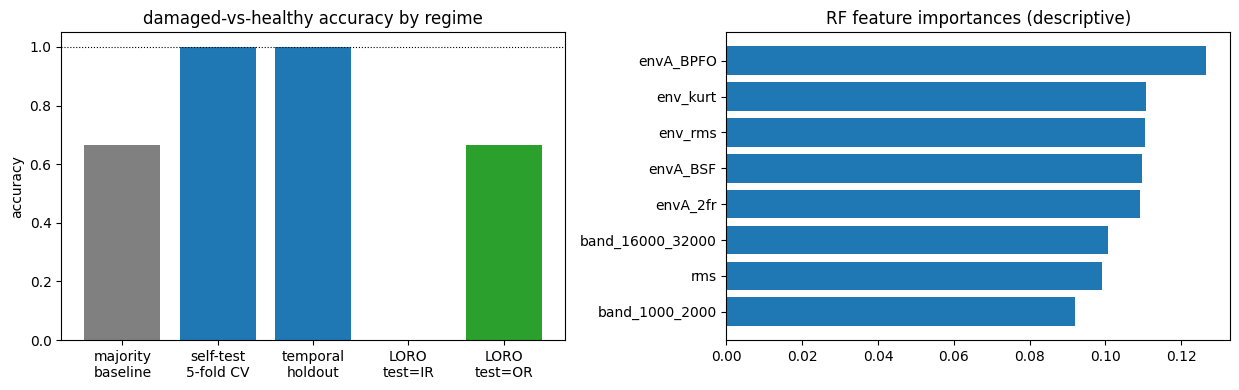


HONEST EVALUATION SUMMARY (put this in the report)
- Regimes (1) and (2) are SELF-TESTS: same-recording windows on both sides of
  the split. They measure within-recording consistency, NOT generalization.
- LORO (3) is the closest we have to generalization; with 3 recordings and only
  1 healthy one, the healthy fold is untrainable -> we CANNOT claim the model
  detects an unseen healthy machine.
- Reference: Paderborn LOBO reports ~68.5% (handcrafted features + SVM) under
  far harder conditions (many machines, speeds, loads). Our setting is one rig,
  one speed, one severity per class -> our high self-test numbers must not be
  read as benchmark-beating. [CAVEAT]



In [10]:
# =====================================================================
# CELL 7 (FIXED) — BINARY MODEL + HONEST EVALUATION
# Fix vs previous version: temporal-holdout block used a per-file t0
# array (15,) against a full-dataset mask (45,) -> broadcast error.
# Now t0 is taken once for the whole DataFrame and indexed by the mask.
# Regimes: (1) window CV = SELF-TEST, (2) temporal holdout = SELF-TEST,
# (3) LORO = closest to generalization (HH fold untrainable).
# Standalone: recomputes windows + features from the CSVs.
# =====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal as sp
from scipy.stats import kurtosis, skew
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
FS = 64_000.0; MASK = (95., 105.)
RAT = {"BPFO": 3.053, "BPFI": 4.947, "BSF": 1.993, "FTF": 0.382}
PATHS = {"HH": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/HH.csv", "IR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/IR.csv", "OR": "/home/shawky/Documents/nti/actual nti/paderborn/Processed subset used in our STR-DDPM experiments/paderborn_subset_used_in_this_study/University of Paderborn Electric Motor Dataset/OR.csv"}
ENVELOPE_MODE = "raw"
WIN = int(0.5*FS); HOP = int(0.25*FS); FTOL = 0.8
def rd(n, col="vibration"): return pd.read_csv(PATHS[n])[col].to_numpy(float)
def xfft(x, pad=4):
    n = (1 << (len(x)-1).bit_length()) * pad
    w = np.hanning(len(x)); X = np.abs(np.fft.rfft(x*w, n))
    return np.fft.rfftfreq(n, 1/FS), X
def pk(f, E, lo, hi):
    i, j = np.searchsorted(f, [lo, hi]); k = i + int(np.argmax(E[i:j]))
    den = E[k-1] - 2*E[k] + E[k+1]
    d = 0.5*(E[k-1] - E[k+1])/den if den < 0 else 0.0
    return f[k] + float(np.clip(d, -1, 1))*(f[1]-f[0]), E[k]
def envspec(x):
    x = x - x.mean()
    if ENVELOPE_MODE == "bp":
        x = sp.sosfiltfilt(sp.butter(4, [2000,15000], btype="band", fs=FS, output="sos"), x)
        x = x - x.mean()
    e = np.abs(sp.hilbert(x)); e = e - e.mean()
    f, E = xfft(e); E[(f>=MASK[0]) & (f<=MASK[1])] = 0.0
    return f, E
def fr_B(x):
    f, X = xfft(x); fe, _ = pk(f, X, 98, 102)
    med = np.median(X[(f>60) & (f<140)])
    g = np.arange(20., 30.0001, .005); a = lambda q: np.interp(q, f, X)/med
    s = np.zeros_like(g)
    for k, w in [(1,1.), (2,.7), (3,.5)]: s += w * a(fe-k*g) * a(fe+k*g)
    return g[int(np.argmax(s))]
def fr_A(x):
    x = x - x.mean(); f, X = xfft(x)
    med = np.median(X[(f>60) & (f<140)])
    g = np.arange(20., 30.0001, .005); a = lambda q: np.interp(q, f, X)/med
    s = a(50-g)*a(50+g) + a(100-g)*a(100+g) + 0.7*a(100-2*g)*a(100+2*g)
    return g[int(np.argmax(s))], float(s.max()/np.median(s))
def fr_C(x):
    e = np.abs(sp.hilbert(x - x.mean())); e = e - e.mean()
    f, E = xfft(e); E[(f>=95) & (f<=105)] = 0.0
    return pk(f, E, 40, 60)[0] / 2
def get_fr():
    out = {}
    for n in PATHS:
        x = rd(n); xb = fr_B(x); xa, ca = fr_A(rd(n, "phase_current_1")); xc = fr_C(x)
        out[n] = 0.5*(xa + xb) if (ca > 1.10 and abs(xa - xb) < 0.2) else xb
    return out
CHAR = [("fr",1.0), ("2fr",2.0), ("3fr",3.0), ("FTF",RAT["FTF"]),
        ("BPFO",RAT["BPFO"]), ("2BPFO",2*RAT["BPFO"]), ("3BPFO",3*RAT["BPFO"]),
        ("BPFI",RAT["BPFI"]), ("2BPFI",2*RAT["BPFI"]), ("BSF",RAT["BSF"])]
def feats(x, fr):
    x = x - x.mean()
    rms = np.sqrt(np.mean(x**2)); pkv = np.max(np.abs(x)); ab = np.mean(np.abs(x))
    tf = {"rms": rms, "peak": pkv, "p2p": np.ptp(x), "crest": pkv/rms,
          "clearance": pkv/np.mean(np.sqrt(np.abs(x)))**2,
          "shape": rms/ab, "impulse": pkv/ab, "kurt": kurtosis(x), "skew": skew(x)}
    f, P = sp.welch(x, FS, nperseg=8192)
    for lo, hi in [(0,1000),(1000,2000),(2000,4000),(4000,8000),(8000,16000),(16000,32000)]:
        tf[f"band_{lo}_{hi}"] = P[(f>=lo) & (f<hi)].sum()/P.sum()
    f, E = envspec(x); base = np.median(E[(f>=2) & (f<=350)])
    for name, ratio in CHAR:
        c = ratio*fr; i, j = np.searchsorted(f, [c-FTOL, c+FTOL])
        tf["envA_" + name] = E[i:j].max()/base
    e = np.abs(sp.hilbert(x)); e = e - e.mean()
    tf["env_rms"] = np.sqrt(np.mean(e**2)); tf["env_kurt"] = kurtosis(e)
    return tf
rows = []
FR = get_fr()
for n in PATHS:
    x = rd(n); fr = FR[n]
    for k, i in enumerate(range(0, len(x)-WIN+1, HOP)):
        d = feats(x[i:i+WIN], fr); d.update(file=n, label=0 if n == "HH" else 1, widx=k, t0=i/FS)
        rows.append(d)
D = pd.DataFrame(rows)
FEATCOLS = [c for c in D.columns if c not in ("file", "label", "widx", "t0")]
X = D[FEATCOLS].to_numpy(float); y = D["label"].to_numpy(int); g = D["file"].to_numpy()
def make_model(name):
    if name == "Dummy(majority)": return DummyClassifier(strategy="most_frequent")
    if name == "RandomForest":    return RandomForestClassifier(n_estimators=300, random_state=0)
    return make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, random_state=0))
RES = {}; RES_LORO = {}
print(f"X {X.shape} | healthy {np.mean(y==0):.2f}, damaged {np.mean(y==1):.2f}")
res_majority = max(float(np.mean(y==0)), float(np.mean(y==1)))
print(f"Majority-class baseline: {res_majority:.3f}\n")

print("== (1) SELF-TEST: stratified 5-fold window CV ==")
print("   [CAVEAT] windows of one recording appear in train AND test -> optimistic.")
for name in ["Dummy(majority)", "RandomForest", "SVM(rbf)"]:
    sc = cross_val_score(make_model(name), X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0))
    RES[name] = float(sc.mean())
    print(f"  {name:16s} acc={sc.mean():.3f} +/- {sc.std():.3f}  folds={np.round(sc,2)}")

print("\n== (2) SELF-TEST (temporal): first 60% of each file train, last 40% test ==")
t0_all = D["t0"].to_numpy(float)                 # <-- FIX: full-column t0, shape (N,)
tr = np.zeros(len(D), bool); te = np.zeros(len(D), bool)
for n in PATHS:
    m = (D.file == n).to_numpy()                 # shape (N,)
    t_cut = 0.6*(t0_all[m].max() + 0.5)          # 60% of the LAST window's END time
    tr |= m & ((t0_all + 0.5) <= t_cut)          # window fully ends before the cut
    te |= m & (t0_all >= t_cut)                  # window fully starts after the cut
print(f"  train {tr.sum()} / test {te.sum()} / dropped {len(D)-int(tr.sum())-int(te.sum())}"
      f" (straddling windows dropped -> no overlap leak)")
print(pd.DataFrame({"file": D.file,
                    "split": np.where(tr, "train", np.where(te, "test", "dropped"))})
      .groupby(["file", "split"]).size().unstack(fill_value=0))
res_temp = {}
for name in ["RandomForest", "SVM(rbf)"]:
    mdl = make_model(name); mdl.fit(X[tr], y[tr])
    acc = float(np.mean(mdl.predict(X[te]) == y[te])); res_temp[name] = acc
    print(f"  {name:16s} acc={acc:.3f}")

print("\n== (3) LORO: train on two recordings, test on the held-out one ==")
for held in ["IR", "OR", "HH"]:
    teL = (g == held); trL = ~teL
    if held == "HH":
        print("  test=HH: SKIPPED as a scored fold -> training set would contain NO healthy")
        print("    recording (IR+OR only). With one healthy file, LORO cannot measure")
        print("    generalization to unseen healthy machines. Demonstration:")
        m = make_model("RandomForest"); m.fit(X[trL], y[trL]); pred = m.predict(X[teL])
        print(f"    model trained without healthy data predicts "
              f"{'damaged' if pred.mean() > 0.5 else 'healthy'} for {pred.mean():.0%} of HH windows")
        print("    -> the limitation is structural, not a tuning issue. [CAVEAT]")
        continue
    m = make_model("RandomForest"); m.fit(X[trL], y[trL]); pred = m.predict(X[teL])
    acc = float(np.mean(pred == y[teL])); RES_LORO[held] = acc
    print(f"  test={held:3s}: window acc={acc:.3f} | {len(pred)} windows | "
          f"majority vote -> {'damaged' if pred.mean() > 0.5 else 'healthy'} ({pred.mean():.0%} 'damaged')")

print("\n== Sanity: label-shuffling null for the self-test [HEURISTIC] ==")
rng = np.random.default_rng(0); accs = []
for _ in range(15):
    yp = rng.permutation(y)
    accs.append(cross_val_score(RandomForestClassifier(n_estimators=100, random_state=0), X, yp,
                                cv=StratifiedKFold(5, shuffle=True, random_state=0)).mean())
print(f"  shuffled labels: acc={np.mean(accs):.3f} +/- {np.std(accs):.3f}  (compare with real self-test)")

m = RandomForestClassifier(n_estimators=500, random_state=0).fit(X, y)
imp = sorted(zip(FEATCOLS, m.feature_importances_), key=lambda t: -t[1])
GLOSS = {"rms": "vibration RMS (energy)", "kurt": "excess kurtosis (impulsiveness)",
         "envA_BPFI": "envelope amp at BPFI x fr", "envA_BPFO": "envelope amp at BPFO x fr",
         "envA_2fr": "envelope amp at 2 x fr", "crest": "crest factor",
         "env_rms": "RMS of envelope", "env_kurt": "kurtosis of envelope"}
print("\nTop-10 RF importances (fit on all windows -> descriptive, NOT a performance claim):")
for c, v in imp[:10]:
    print(f"  {c:14s} {v:.3f}   {GLOSS.get(c, '')}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
bars = ["majority\nbaseline", "self-test\n5-fold CV", "temporal\nholdout", "LORO\ntest=IR", "LORO\ntest=OR"]
vals = [res_majority, RES["RandomForest"], res_temp["RandomForest"], RES_LORO["IR"], RES_LORO["OR"]]
axes[0].bar(bars, vals, color=["grey", "tab:blue", "tab:blue", "tab:green", "tab:green"])
axes[0].set_ylim(0, 1.05); axes[0].axhline(1.0, ls=":", c="k", lw=.8)
axes[0].set_ylabel("accuracy"); axes[0].set_title("damaged-vs-healthy accuracy by regime")
axes[1].barh([c for c, _ in imp[:8]][::-1], [v for _, v in imp[:8]][::-1])
axes[1].set_title("RF feature importances (descriptive)")
plt.tight_layout(); plt.show()

print("""
HONEST EVALUATION SUMMARY (put this in the report)
- Regimes (1) and (2) are SELF-TESTS: same-recording windows on both sides of
  the split. They measure within-recording consistency, NOT generalization.
- LORO (3) is the closest we have to generalization; with 3 recordings and only
  1 healthy one, the healthy fold is untrainable -> we CANNOT claim the model
  detects an unseen healthy machine.
- Reference: Paderborn LOBO reports ~68.5% (handcrafted features + SVM) under
  far harder conditions (many machines, speeds, loads). Our setting is one rig,
  one speed, one severity per class -> our high self-test numbers must not be
  read as benchmark-beating. [CAVEAT]
""")